# Implementation of the elicitation procedure 

In [1]:
import os
import sys

sys.path.append("../")

import matplotlib.pyplot as plt
import numpy as np

In [2]:
from python.decision_maker import DecisionMaker, HiddenDecisionMakers
from python.query import NeighboringRectanglesQuery, SingleRectangleQuery
from python.identify import UTAsIdentification

### Drawing Random Decision Makers whose value functions are piecewise linear and increasing (UTAs)

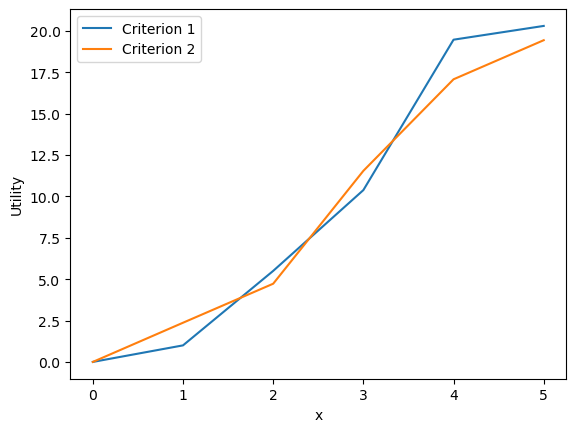

In [17]:
# Draw and plot a DM with a value function with 2 criteria and 5 pieces
single_dm = DecisionMaker(n_criteria=2, n_pieces=5)
single_dm.plot_decision_function()

DM1:


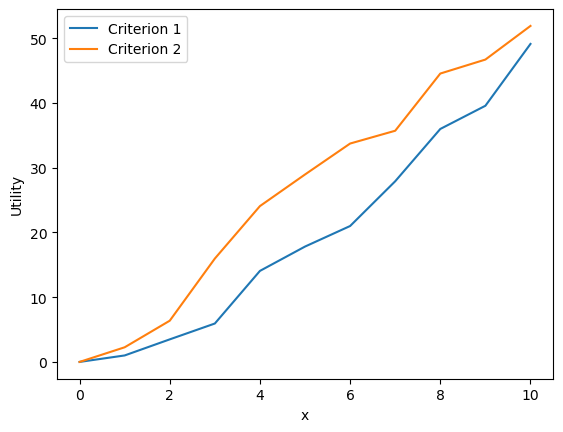

DM2:


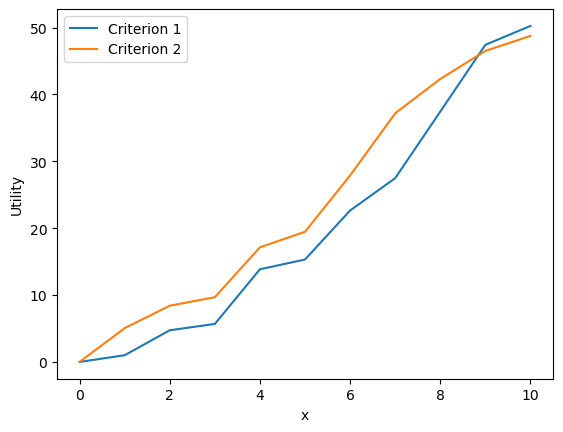

In [20]:
# Draw 2 Hidden Decision Makers with value functions with 2 criteria and 10 pieces

hdm = HiddenDecisionMakers(n_dms=2, n_criteria=2, n_pieces=10)
print("DM1:")
hdm.dms[0].plot_decision_function()
print("DM2:")
hdm.dms[1].plot_decision_function()

In [21]:
print("DM1 slopes:", hdm.dms[0].slopes)
print("DM2 slopes:", hdm.dms[1].slopes)

DM1 slopes: [[1.         2.48457318 2.44845455 8.1283057  3.75964331 3.17478851
  6.91310116 8.07971295 3.58376317 9.55327434]
 [2.26107154 4.10661561 9.60017003 8.10534098 4.88389733 4.77942129
  1.97603293 8.83675388 2.15838272 5.1985119 ]]
DM2 slopes: [[1.         3.73580123 0.94417137 8.17635225 1.45984248 7.33420103
  4.83159064 9.96779438 9.9763838  2.82658455]
 [5.04757107 3.35846576 1.27176819 7.46145713 2.32726346 8.42481427
  9.29337469 5.136853   4.19380999 2.24200224]]


## Identification

In [23]:
# Instantiate identification class
identif = UTAsIdentification(n_criteria=2, n_pieces=10)
# Identify
identif.identify_hdms(hdms=hdm)

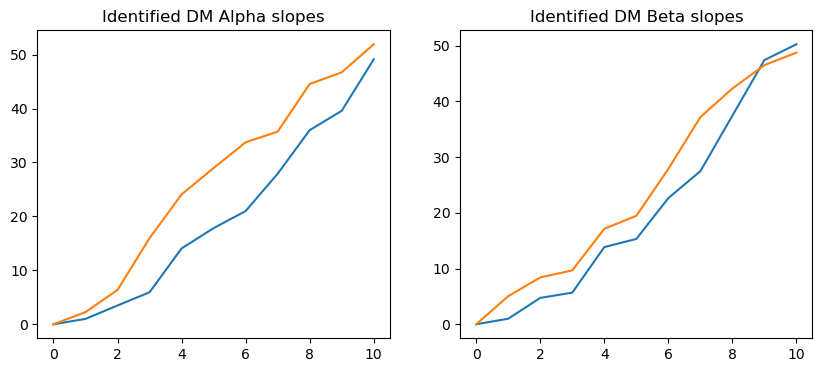

Ground Truth Value Functions:


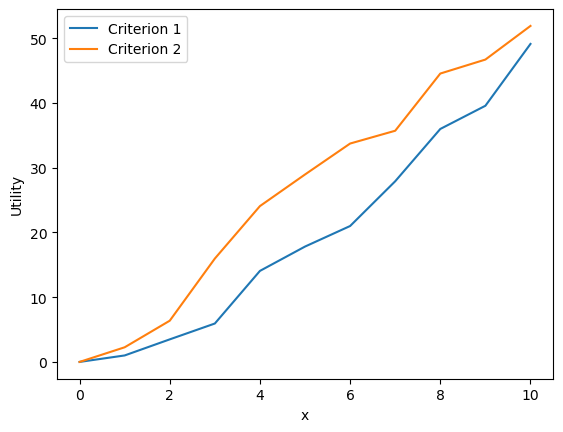

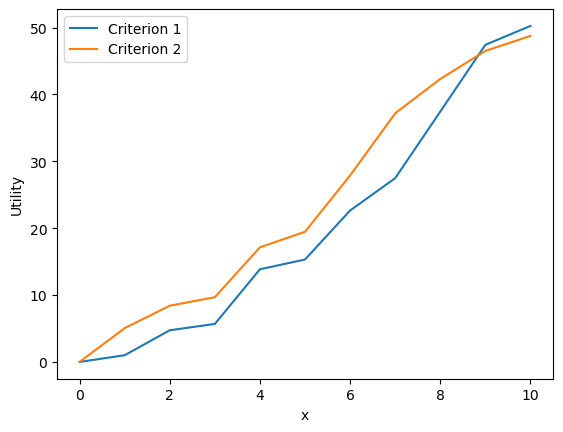

In [25]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
alpha_0 = [0]
for i in identif.slopes["alpha"][0]:
    alpha_0.append(i + alpha_0[-1])
alpha_1 = [0]
for i in identif.slopes["alpha"][1]:
    alpha_1.append(i + alpha_1[-1])
plt.plot(alpha_0)
plt.title("Identified DM Alpha slopes")
plt.plot(alpha_1)

plt.subplot(1, 2, 2)
beta_0 = [0]
for i in identif.slopes["beta"][0]:
    beta_0.append(i + beta_0[-1])
beta_1 = [0]
for i in identif.slopes["beta"][1]:
    beta_1.append(i + beta_1[-1])
plt.plot(beta_0)
plt.plot(beta_1)
plt.title("Identified DM Beta slopes")
plt.show()

print("Ground Truth Value Functions:")
hdm.dms[0].plot_decision_function()
hdm.dms[1].plot_decision_function()